# Topology optimization of an MBB beam
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/optimization/planar/topology.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/optimization/planar/topology.ipynb)

We minimize the compliance of the classic half-MBB beam at a fixed material budget with SIMP topology optimization. Because *torch-fem* is fully differentiable, the design sensitivities can be obtained either from the well-known analytical expression or directly via automatic differentiation.

## Model

We discretize the beam with a structured mesh of $60 \times 20$ quadrilaterals of unit edge length using the `rect_quad` helper from the `torchfem.mesh` subpackage. Exploiting symmetry, we model only the right half of the beam: the left edge is a symmetry plane (no horizontal displacement), a roller support carries the vertical reaction in the bottom right corner, and the downward load is applied in the top left corner.

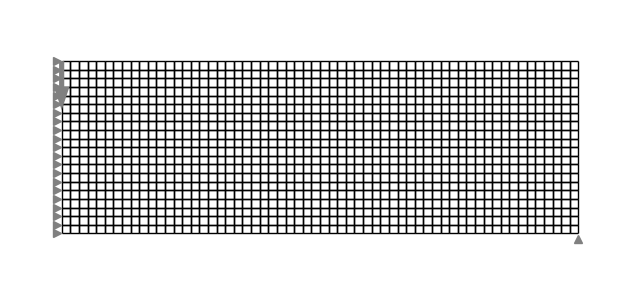

In [1]:
import torch

torch.set_default_dtype(torch.double)

from torchfem import Planar
from torchfem.materials import IsotropicElasticityPlaneStress
from torchfem.mesh import rect_quad

# Domain of 60 x 20 quadrilaterals with unit edge length
Nx, Ny = 60, 20
nodes, elements = rect_quad(Nx + 1, Ny + 1, Nx, Ny)

# Plane stress material and planar model
material = IsotropicElasticityPlaneStress(E=100.0, nu=0.3)
model = Planar(nodes, elements, material)

# Symmetry support on the left edge and a roller in the bottom right corner
model.constraints[nodes[:, 0] == 0.0, 0] = True
model.constraints[(nodes[:, 0] == Nx) & (nodes[:, 1] == 0.0), 1] = True

# Downward point load in the top left corner
model.forces[(nodes[:, 0] == 0.0) & (nodes[:, 1] == Ny), 1] = -1.0

# Plot the domain
model.plot()

## Optimization

We minimize compliance for a prescribed volume fraction via optimality criteria. Each element carries a design density $\rho_e \in [\rho_\text{min}, 1]$ that scales its thickness through the SIMP penalization $\rho_e^p$, so that intermediate densities become uneconomical and the design converges towards a black-and-white layout. To suppress checkerboard patterns, the sensitivities are smoothed with a linear filter $\mathbf{H}$ built from the distances between element centroids.

In [2]:
# volume fraction constraint
vol_frac = 0.5
# SIMP penalization exponent
p = 3.0
# sensitivity filter radius
filter_radius = 1.5
# move limit of the optimality criteria update
move = 0.2

# Design variables (element densities) and their bounds
rho = vol_frac * torch.ones(len(elements))
rho_min, rho_max = 0.01, 1.0

# Element areas and the target volume
areas = model.integrate_field()
V_0 = vol_frac * areas.sum()

# Unit-thickness element stiffness matrices for the analytical sensitivity
k0 = torch.einsum("i,ijk->ijk", 1.0 / model.thickness, model.k0())

# Linear filter weights between element centroids
centroids = nodes[elements].mean(dim=1)
H = torch.clamp(filter_radius - torch.cdist(centroids, centroids), min=0.0)

The optimization loop below supports two ways of computing the compliance sensitivities $\frac{\partial C}{\partial \rho_e}$, selected via `TORCH_SENS`:

- `TORCH_SENS = False` uses the well-established analytical expression $\frac{\partial C}{\partial \rho_e} = -p\, \rho_e^{p-1}\, \mathbf{u}_e \cdot \mathbf{k}_{0,e} \cdot \mathbf{u}_e$.
- `TORCH_SENS = True` obtains the same gradient via automatic differentiation through the FEM solve.

Both variants converge to the same design — the two sensitivities agree down to machine precision. Automatic differentiation is only a little slower, yet it removes the need to derive and implement sensitivities by hand, which is valuable whenever an analytical expression is not readily available.

In [3]:
from scipy.optimize import bisect
from tqdm import tqdm

TORCH_SENS = False

rho_history = [rho]
for k in tqdm(range(100)):
    rho_k = rho_history[k].requires_grad_()

    # Solve with SIMP-penalized densities as element thickness
    model.thickness = rho_k**p
    u_k, f_k, _, _, _ = model.solve(differentiable_parameters=rho_k)

    # Compliance
    compliance = torch.inner(f_k.ravel(), u_k.ravel())

    if TORCH_SENS:
        # Sensitivity via automatic differentiation
        sensitivity = torch.autograd.grad(compliance, rho_k)[0]
    else:
        # Analytical sensitivity  dC/drho = -p rho^(p-1) u.k0.u
        u_e = u_k[elements].reshape(model.n_elem, -1)
        w_k = torch.einsum("...i,...ij,...j", u_e, k0, u_e)
        sensitivity = -p * rho_k ** (p - 1.0) * w_k

    # Smooth the sensitivities with the linear filter
    sensitivity = H @ (rho_k * sensitivity) / H.sum(dim=0) / rho_k

    # Optimality criteria update with bisection on the Lagrange multiplier mu
    with torch.no_grad():
        lower = torch.clamp((1 - move) * rho_k, min=rho_min)
        upper = torch.clamp((1 + move) * rho_k, max=rho_max)

        def make_step(mu):
            rho_trial = rho_k * torch.sqrt(-sensitivity / mu)
            return torch.clamp(rho_trial, lower, upper)

        mu = bisect(lambda mu: torch.dot(areas, make_step(mu)) - V_0, 1e-10, 1e2)
        rho_history.append(make_step(mu))

100%|██████████| 100/100 [00:02<00:00, 49.55it/s]


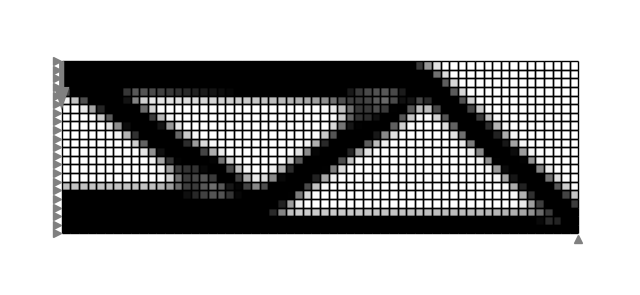

In [4]:
model.plot(element_property=rho_history[-1].detach(), cmap="gray_r")